# Notebook 02 — Tissue Segmentation

**MALDI-MSI Analysis of Mouse Urinary Bladder**  
Author: Reza Rajaee

---

## What this notebook covers

1. How to choose the number of clusters (k) — statistical + biological evidence
2. K-means segmentation
3. GMM (Gaussian Mixture Model) segmentation
4. Spectral clustering segmentation
5. Comparing the three segmentation maps
6. Where do the methods agree and disagree? (label-aligned)
7. PCA and t-SNE coloured by cluster assignments

---

## Why segment MALDI-MSI data?

Segmentation groups pixels with similar molecular profiles into regions.
The resulting map — called a **molecular segmentation map** — reveals
tissue organisation based on molecular composition rather than morphology.

For the mouse bladder, we expect to recover three tissue layers:
urothelium, muscle, and connective tissue — each with distinct lipid profiles.

References:
- Alexandrov et al. (2010) *J. Proteome Res.* 9:6535 — K-means for MSI
- Bemis, Föll et al. (2023) *Nature Methods* 20:1883 — SSC segmentation
- Reynolds (2009) *Encyclopedia of Biometrics* — GMM overview

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import sys, os

os.chdir("/workspaces/maldi-msi-analysis")
sys.path.insert(0, "/workspaces/maldi-msi-analysis")

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables",  exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                      "axes.spines.top": False,
                      "axes.spines.right": False})
print("Setup complete.")
print("Working directory:", os.getcwd())


Setup complete.
Working directory: /workspaces/maldi-msi-analysis


## 1. Load Preprocessed Data

In [2]:
spectra_pp  = np.load("results/spectra_preprocessed.npy")
ref_mz      = np.load("results/reference_mz.npy")
pc_after    = np.load("results/pca_embedding.npy")
X_tsne      = np.load("results/tsne_embedding.npy")
coordinates = pd.read_csv("results/coordinates.csv")

x = coordinates["x"].values.astype(int) - coordinates["x"].min()
y = coordinates["y"].values.astype(int) - coordinates["y"].min()

print(f"Loaded: {spectra_pp.shape[0]} pixels × {spectra_pp.shape[1]} peaks")
print(f"PCA embedding shape: {pc_after.shape}")

# Use first 10 PCs as clustering input — no StandardScaler
# StandardScaler is wrong for MSI: it gives equal weight to noise peaks
# and dominant lipid signals. TIC normalisation already made intensities
# comparable. PCA reduces noise dimensions before clustering.
X_clust = pc_after[:, :10]
print(f"Clustering input: first 10 PCs  {X_clust.shape}")
print(f"Variance captured: {pc_after[:, :10].var(axis=0).sum():.4f}")

Loaded: 34840 pixels × 153 peaks
PCA embedding shape: (34840, 10)
Clustering input: first 10 PCs  (34840, 10)
Variance captured: 0.0585


## 2. How Many Clusters? Statistical Evidence

Before segmenting, we need to decide how many regions (k) to look for.
We use two statistical methods:

### Elbow curve
Plot the total within-cluster variance (inertia) vs k.
The "elbow" — where the curve bends — suggests the optimal k.
Beyond this point, adding more clusters gives diminishing returns.

### Silhouette score
Measures how well each pixel fits its assigned cluster vs
neighbouring clusters. Range: -1 to 1, higher = better.
The k with the highest silhouette score is statistically optimal.

**Important:** We compute both metrics on the **first 10 PCs**, not the
raw 153-dimensional feature matrix. In high dimensions, Euclidean distances
become unreliable (curse of dimensionality), making silhouette scores
uninformative. The first 10 PCs capture the dominant biological variance
while removing noisy dimensions.

Reference: Rousseeuw (1987) *J. Comput. Appl. Math.* 20:53

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range     = range(2, 9)
inertias    = []
silhouettes = []

print("Computing elbow curve and silhouette scores on first 10 PCs...")
for k in k_range:
    km     = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil    = silhouette_score(X_clust, labels, random_state=42)
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

# Let the data decide k — do not hardcode
best_k_silhouette = list(k_range)[np.argmax(silhouettes)]

inertias_arr  = np.array(inertias)
deltas        = np.diff(inertias_arr)
curvature     = np.diff(deltas)
best_k_elbow  = list(k_range)[np.argmax(np.abs(curvature)) + 1]

print(f"\nSilhouette suggests: k={best_k_silhouette}")
print(f"Elbow suggests:      k={best_k_elbow}")

Computing elbow curve and silhouette scores on first 10 PCs...
  k=2: inertia=1285.29, silhouette=0.4952
  k=3: inertia=812.22, silhouette=0.4366
  k=4: inertia=635.76, silhouette=0.3745
  k=5: inertia=498.35, silhouette=0.3609
  k=6: inertia=441.01, silhouette=0.3256
  k=7: inertia=397.43, silhouette=0.3050
  k=8: inertia=363.63, silhouette=0.2987

Silhouette suggests: k=2
Elbow suggests:      k=3


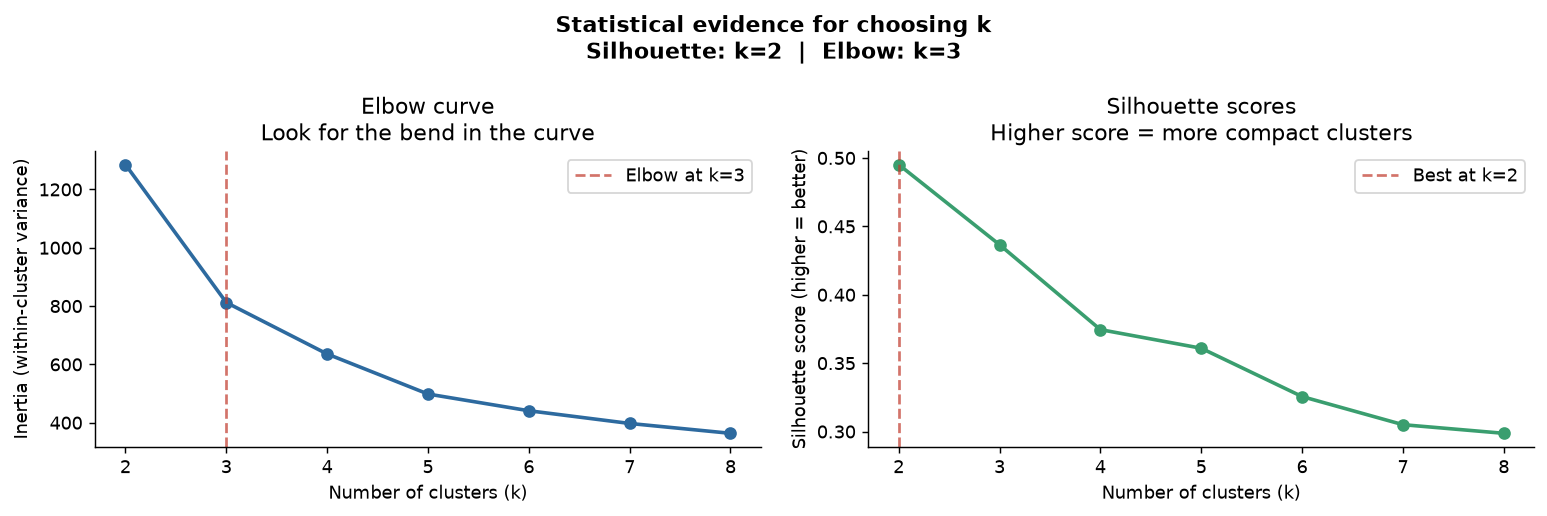

Figure saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, "o-", color="#2d6a9f", linewidth=2)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster variance)")
axes[0].set_title("Elbow curve\nLook for the bend in the curve")
axes[0].axvline(x=best_k_elbow, color="#c0392b", linestyle="--",
                linewidth=1.5, alpha=0.7, label=f"Elbow at k={best_k_elbow}")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, "o-", color="#3a9e6f", linewidth=2)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score (higher = better)")
axes[1].set_title("Silhouette scores\nHigher score = more compact clusters")
axes[1].axvline(x=best_k_silhouette, color="#c0392b", linestyle="--",
                linewidth=1.5, alpha=0.7, label=f"Best at k={best_k_silhouette}")
axes[1].legend()

fig.suptitle(f"Statistical evidence for choosing k\n"
             f"Silhouette: k={best_k_silhouette}  |  Elbow: k={best_k_elbow}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/02_elbow_silhouette.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 3. Choosing k — Statistical + Biological Evidence

The statistical analysis above gives data-driven suggestions for k.
We now reconcile this with biological prior knowledge.

**Mouse urinary bladder has three known anatomical layers:**

1. **Urothelium** — specialized epithelial cells, high in specific
   phospholipids forming the permeability barrier
2. **Muscle layer** — smooth muscle cells with high sphingomyelin content
3. **Connective tissue** — collagen-rich extracellular matrix,
   distinct lipid profile from the other layers

**Reconciling statistics and biology:**

If silhouette peaks at k=2, this suggests the data has two dominant
molecular compartments — likely inner epithelium vs outer layers combined.
The third layer may be molecularly similar to one of the two dominant groups
and only separates at k=3. This is biologically plausible: muscle and
connective tissue share some lipid classes while urothelium is highly distinct.

We proceed with **k=3** to match the known anatomy, while acknowledging
that the statistical evidence is strongest for k=2. This is a deliberate
biological decision, not an oversight — and it is standard practice in
MSI segmentation to let anatomical knowledge guide k when statistical
evidence is ambiguous.

Reference: Römpp et al. (2010) *Angew. Chem. Int. Ed.* 49:3834

## 4. K-means Segmentation

K-means partitions pixels into k groups by minimising the total
within-cluster variance. Each pixel is assigned to the cluster
whose centroid (mean spectrum) is closest in Euclidean distance.

Advantages: fast, simple, interpretable
Limitations: assumes spherical clusters, sensitive to initialisation

Reference: Alexandrov et al. (2010) *J. Proteome Res.* 9:6535


In [5]:
K = 3

km        = KMeans(n_clusters=K, n_init=20, random_state=42)
labels_km = km.fit_predict(X_clust)

print(f"K-means (k={K}) complete.")
unique, counts = np.unique(labels_km, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} pixels ({c/len(labels_km)*100:.1f}%)")

K-means (k=3) complete.
  Cluster 0: 4483 pixels (12.9%)
  Cluster 1: 7833 pixels (22.5%)
  Cluster 2: 22524 pixels (64.6%)


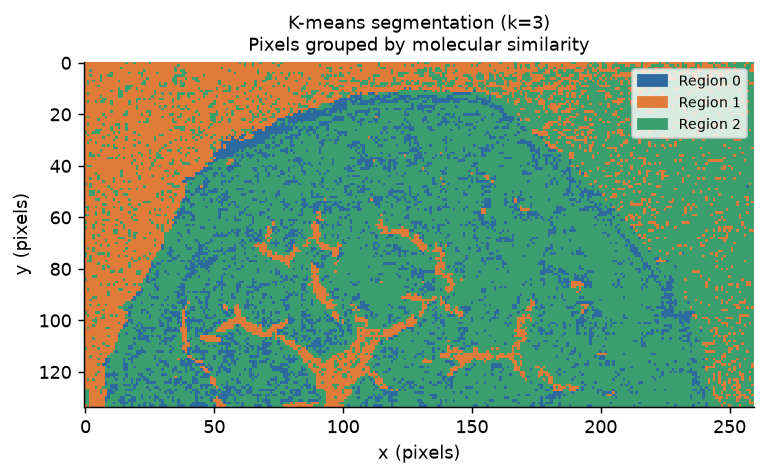

Figure saved.


In [6]:
from src.visualisation import plot_segmentation, CLUSTER_COLOURS

fig, ax = plt.subplots(figsize=(6, 5))
plot_segmentation(labels_km, coordinates,
                  title=f"K-means segmentation (k={K})\n"
                        "Pixels grouped by molecular similarity",
                  ax=ax, show=False)
plt.tight_layout()
plt.savefig("results/figures/02_kmeans_segmentation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 5. GMM Segmentation

Gaussian Mixture Models model the data as a mixture of Gaussian
distributions. Unlike K-means (hard assignment), GMM gives each
pixel a **probability of belonging to each cluster** (soft assignment).

This is useful because tissue boundaries are not sharp —
pixels at the boundary between two regions have intermediate
molecular profiles and genuinely belong partially to both.

Advantages: soft assignments, models cluster shape and uncertainty
Limitations: more parameters, can overfit, slower than K-means

Reference: Reynolds (2009) *Encyclopedia of Biometrics* — GMM overview


In [7]:
from sklearn.mixture import GaussianMixture

gmm        = GaussianMixture(n_components=K, n_init=5,
                              random_state=42, covariance_type="full")
gmm.fit(X_clust)
labels_gmm = gmm.predict(X_clust)
proba_gmm  = gmm.predict_proba(X_clust)

print(f"GMM (k={K}) complete.")
print(f"  Log-likelihood: {gmm.lower_bound_:.4f}")
unique, counts = np.unique(labels_gmm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Component {u}: {c} pixels ({c/len(labels_gmm)*100:.1f}%)")

GMM (k=3) complete.
  Log-likelihood: 25.6202
  Component 0: 15426 pixels (44.3%)
  Component 1: 8894 pixels (25.5%)
  Component 2: 10520 pixels (30.2%)


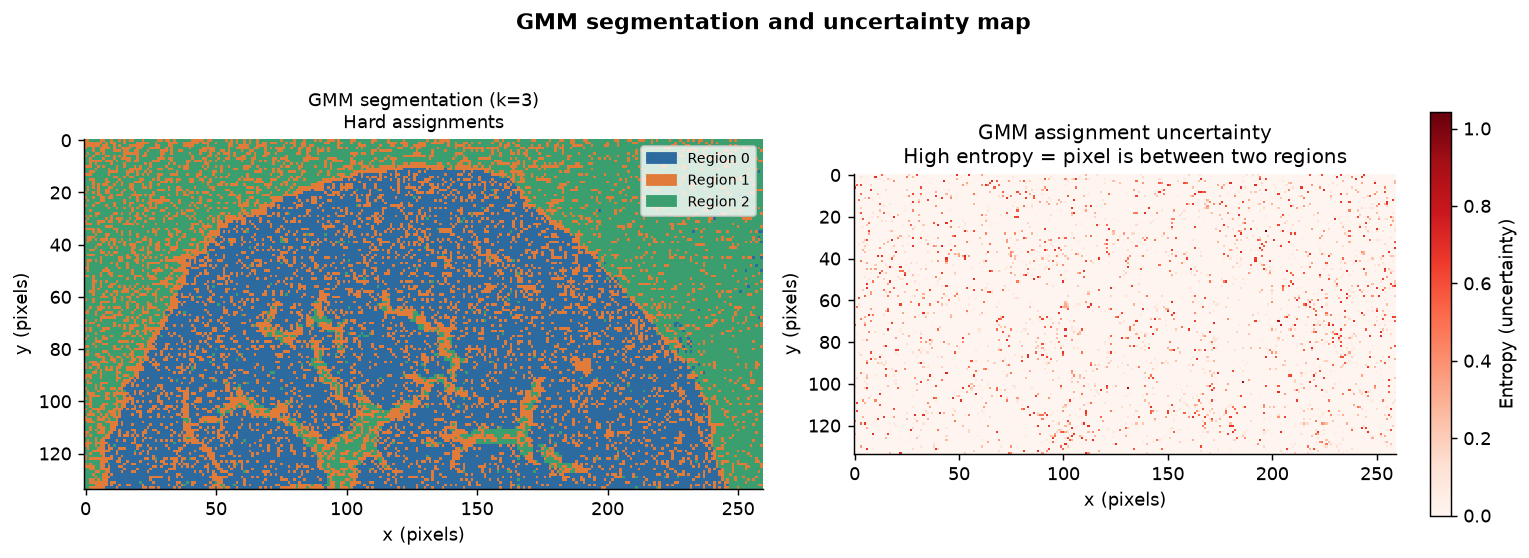

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_segmentation(labels_gmm, coordinates,
                  title=f"GMM segmentation (k={K})\nHard assignments",
                  ax=axes[0], show=False)

# Show uncertainty map — entropy of probability distribution
entropy = -np.sum(proba_gmm * np.log(proba_gmm + 1e-10), axis=1)
ent_map = np.full((y.max()+1, x.max()+1), np.nan)
ent_map[y, x] = entropy

im = axes[1].imshow(ent_map, cmap="Reds",
                    interpolation="nearest", aspect="equal")
plt.colorbar(im, ax=axes[1], label="Entropy (uncertainty)", shrink=0.8)
axes[1].set_title("GMM assignment uncertainty\n"
                  "High entropy = pixel is between two regions")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")

fig.suptitle("GMM segmentation and uncertainty map",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/02_gmm_segmentation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 6. Spectral Clustering

Spectral clustering constructs a similarity graph between pixels
and finds clusters by partitioning this graph. It can find
non-convex cluster shapes that K-means and GMM cannot.

**Why `nearest_neighbors` affinity instead of `rbf`:**  
`affinity="rbf"` computes similarity between every pair of pixels,
building a dense n×n matrix. For 34,840 pixels that is 1.2 billion
pairwise computations — taking hours and gigabytes of memory.  
`affinity="nearest_neighbors"` builds a sparse graph connecting each
pixel to its 10 nearest neighbours only. This scales as O(n·k) and
runs in minutes on the full dataset, making it the correct choice
for large MSI datasets.

Advantages: handles non-convex shapes, graph-based, no density assumption  
Limitations: eigendecomposition can be slow for very large datasets

Reference: Von Luxburg (2007) *Stat. Comput.* 17:395

In [9]:
from sklearn.cluster import SpectralClustering

n_px = X_clust.shape[0]
print(f"Running Spectral Clustering on {n_px} pixels...")
print("affinity=nearest_neighbors — sparse graph, avoids dense n×n matrix")

sc        = SpectralClustering(n_clusters=K, random_state=42,
                                affinity="nearest_neighbors",
                                n_neighbors=10,
                                n_init=5,
                                assign_labels="kmeans")
labels_sc = sc.fit_predict(X_clust)

print(f"Spectral Clustering (k={K}) complete.")
unique, counts = np.unique(labels_sc, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} pixels ({c/len(labels_sc)*100:.1f}%)")

Running Spectral Clustering on 34840 pixels...
affinity=nearest_neighbors — sparse graph, avoids dense n×n matrix
Spectral Clustering (k=3) complete.
  Cluster 0: 23375 pixels (67.1%)
  Cluster 1: 11314 pixels (32.5%)
  Cluster 2: 151 pixels (0.4%)


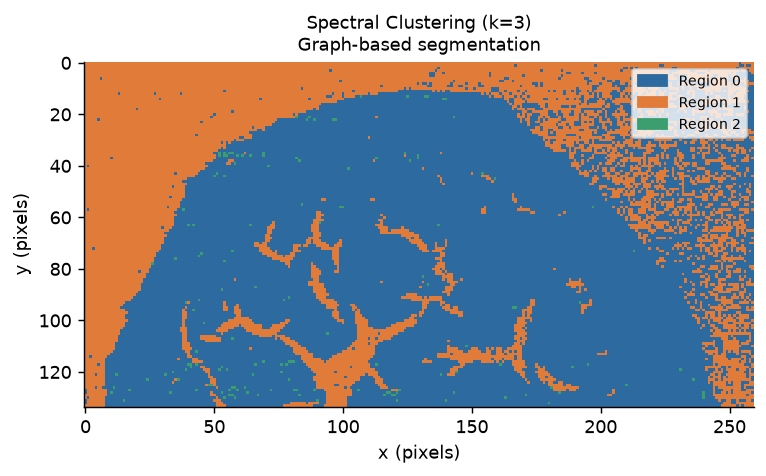

Figure saved.


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_segmentation(labels_sc, coordinates,
                  title=f"Spectral Clustering (k={K})\n"
                        "Graph-based segmentation",
                  ax=ax, show=False)
plt.tight_layout()
plt.savefig("results/figures/02_spectral_segmentation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 7. Comparing All Three Methods

We plot the three segmentation maps side by side.
Then we measure pairwise similarity using ARI (Adjusted Rand Index).

ARI = 1: identical segmentation
ARI = 0: no better than random
ARI > 0.8: high agreement

Reference: Hubert & Arabie (1985) *J. Classification* 2:193


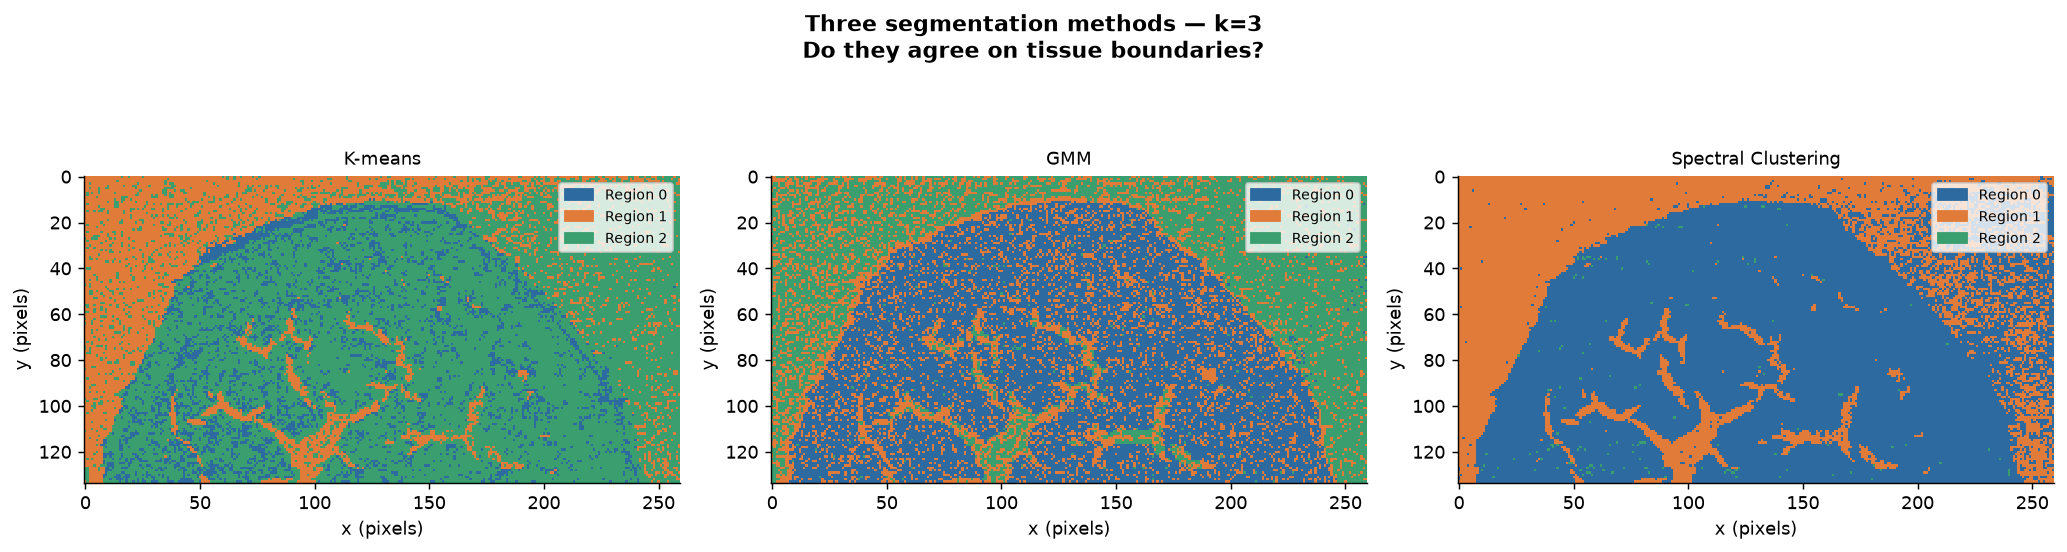

Figure saved.

Pairwise ARI (agreement between methods):
  K-means vs GMM:      0.1382
  K-means vs Spectral: 0.4259
  GMM vs Spectral:     0.3108

Interpretation:
  ARI > 0.8: high agreement
  ARI > 0.6: moderate agreement
  ARI < 0.6: methods disagree substantially


In [11]:
from sklearn.metrics import adjusted_rand_score

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, labels, title in zip(
    axes,
    [labels_km, labels_gmm, labels_sc],
    ["K-means", "GMM", "Spectral Clustering"]
):
    plot_segmentation(labels, coordinates,
                      title=title, ax=ax, show=False)

fig.suptitle(f"Three segmentation methods — k={K}\n"
             "Do they agree on tissue boundaries?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/02_comparison_all3.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

# ARI — permutation-invariant, correct comparison
ari_km_gmm = adjusted_rand_score(labels_km, labels_gmm)
ari_km_sc  = adjusted_rand_score(labels_km, labels_sc)
ari_gmm_sc = adjusted_rand_score(labels_gmm, labels_sc)

print(f"\nPairwise ARI (agreement between methods):")
print(f"  K-means vs GMM:      {ari_km_gmm:.4f}")
print(f"  K-means vs Spectral: {ari_km_sc:.4f}")
print(f"  GMM vs Spectral:     {ari_gmm_sc:.4f}")
print(f"\nInterpretation:")
print(f"  ARI > 0.8: high agreement")
print(f"  ARI > 0.6: moderate agreement")
print(f"  ARI < 0.6: methods disagree substantially")

## 8. Disagreement Analysis

Where do the methods disagree?

**Critical methodological note:**  
Simply comparing `labels_km == labels_gmm` is wrong — the three methods
assign arbitrary numbers to regions. K-means might call urothelium "0"
while GMM calls it "2". A naive comparison counts this as disagreement
even though both methods found the same region.

We first **align labels** using the Hungarian algorithm, which finds the
optimal permutation of labels that maximises overlap between two segmentations.
Only after alignment is the pixel-level agreement comparison meaningful.

Disagreement pixels after alignment are most likely at true tissue boundaries
where the molecular profile is intermediate between two regions.

After label alignment (Hungarian algorithm):
  Pixels where all 3 methods agree:  16145 (46.3%)
  Pixels where methods disagree:     18695 (53.7%)


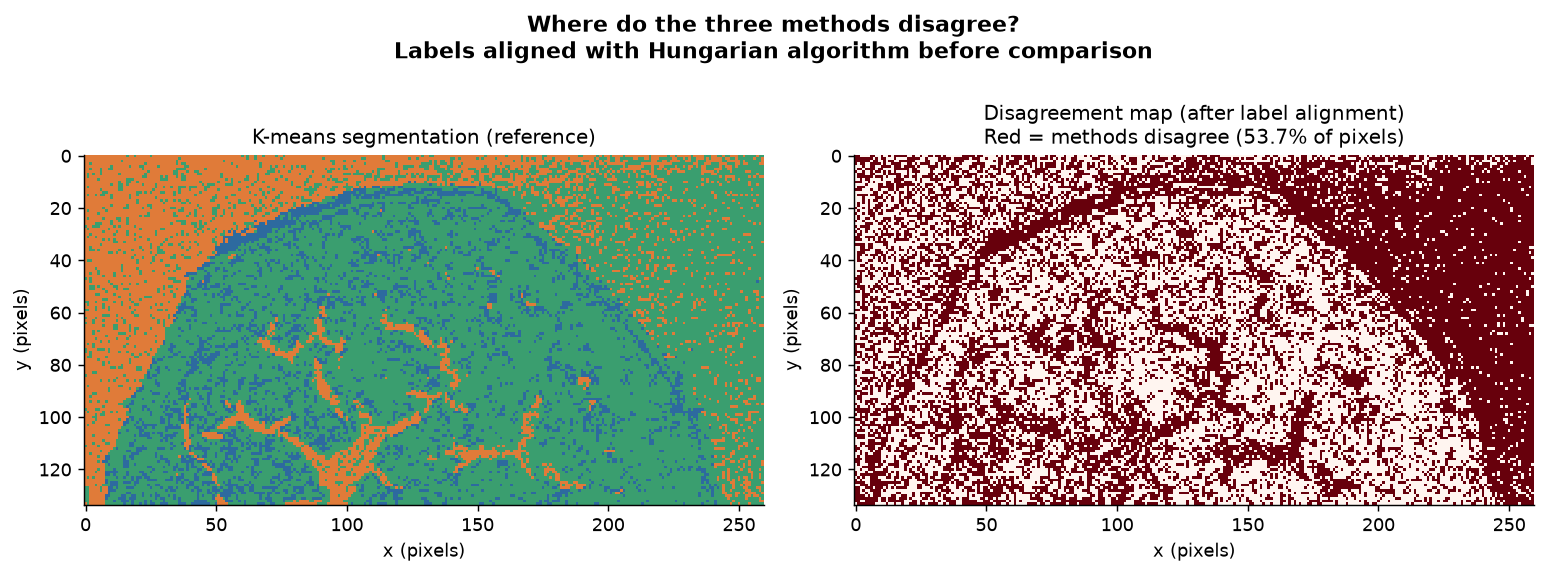

Figure saved.


In [12]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def align_labels(labels_ref, labels_other, K):
    """
    Permute labels_other to best match labels_ref.
    Uses Hungarian algorithm to maximise pixel-level overlap.
    Required before any pixel-level agreement comparison.
    """
    cm = confusion_matrix(labels_ref, labels_other)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[l] for l in labels_other])

# Align GMM and Spectral labels to K-means reference
labels_gmm_aligned = align_labels(labels_km, labels_gmm, K)
labels_sc_aligned  = align_labels(labels_km, labels_sc,  K)

# Now comparison is meaningful — same number = same region
agree_all = (labels_km == labels_gmm_aligned) & (labels_km == labels_sc_aligned)
disagree  = ~agree_all

print(f"After label alignment (Hungarian algorithm):")
print(f"  Pixels where all 3 methods agree:  {agree_all.sum()} "
      f"({agree_all.mean()*100:.1f}%)")
print(f"  Pixels where methods disagree:     {disagree.sum()} "
      f"({disagree.mean()*100:.1f}%)")

# Disagreement map
disagree_map = np.full((y.max()+1, x.max()+1), np.nan)
disagree_map[y, x] = disagree.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Reference segmentation
seg_map = np.full((y.max()+1, x.max()+1), np.nan)
seg_map[y, x] = labels_km.astype(float)

cmap_seg   = mcolors.ListedColormap(["#2d6a9f", "#e07b39", "#3a9e6f"])
bounds_seg = [-0.5, 0.5, 1.5, 2.5]
norm_seg   = mcolors.BoundaryNorm(bounds_seg, cmap_seg.N)

axes[0].imshow(seg_map, cmap=cmap_seg, norm=norm_seg,
               interpolation="nearest", aspect="equal")
axes[0].set_title("K-means segmentation (reference)")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")

axes[1].imshow(disagree_map, cmap="Reds",
               interpolation="nearest", aspect="equal",
               vmin=0, vmax=1)
axes[1].set_title(f"Disagreement map (after label alignment)\n"
                  f"Red = methods disagree ({disagree.mean()*100:.1f}% of pixels)")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")

fig.suptitle("Where do the three methods disagree?\n"
             "Labels aligned with Hungarian algorithm before comparison",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/02_disagreement_map.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Molecular profile at disagreement pixels

What is special about the disagreement pixels molecularly?
We compare mean spectra of agreement vs disagreement pixels.


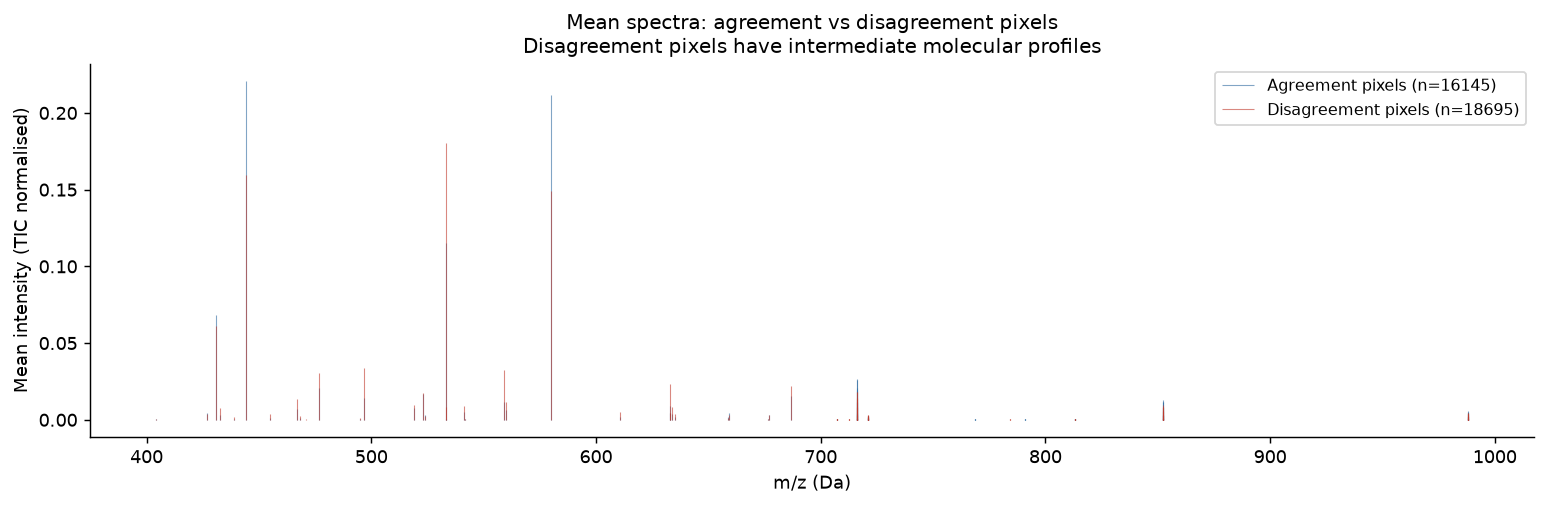

Figure saved.


In [13]:
mean_agree    = spectra_pp[agree_all].mean(axis=0)
mean_disagree = spectra_pp[disagree].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.vlines(ref_mz, ymin=0, ymax=mean_agree,
          linewidth=0.6, color="#2d6a9f", alpha=0.6,
          label=f"Agreement pixels (n={agree_all.sum()})")
ax.vlines(ref_mz, ymin=0, ymax=mean_disagree,
          linewidth=0.6, color="#c0392b", alpha=0.6,
          label=f"Disagreement pixels (n={disagree.sum()})")
ax.set_xlabel("m/z (Da)")
ax.set_ylabel("Mean intensity (TIC normalised)")
ax.set_title("Mean spectra: agreement vs disagreement pixels\n"
             "Disagreement pixels have intermediate molecular profiles")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/02_disagree_spectra.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 9. PCA and t-SNE Coloured by Cluster Labels

We project the cluster assignments back onto the PCA and t-SNE embeddings
computed in notebook 01. This validates whether the clusters found by
our algorithms correspond to the visual groups in the 2D projection.

If the clusters are meaningful, each algorithm's assignments should
align well with the groups visible in t-SNE space.


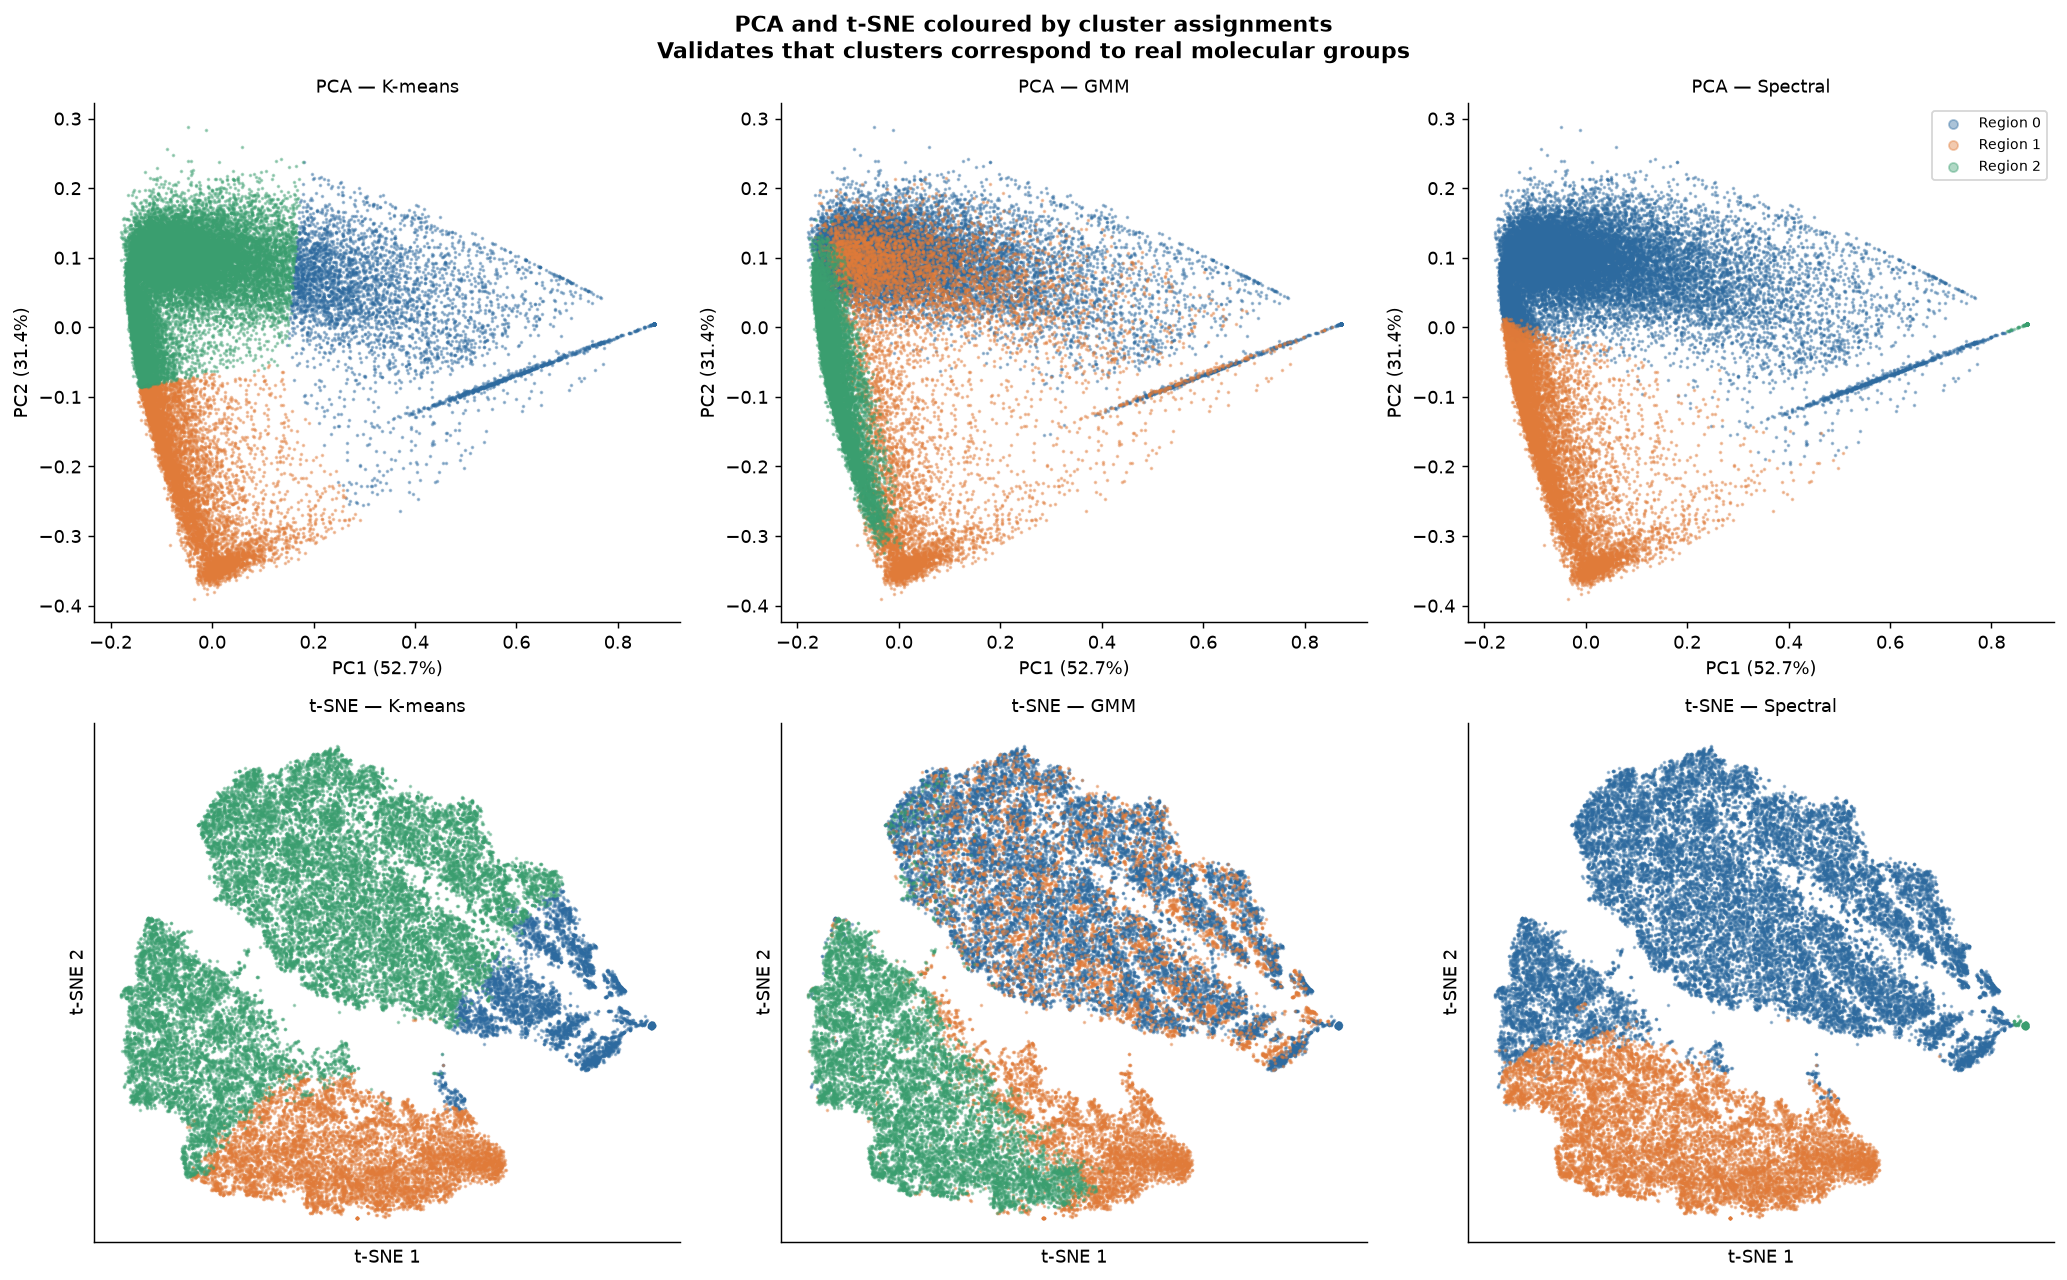

Figure saved.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

embeddings = [pc_after, X_tsne]
emb_names  = ["PCA", "t-SNE"]
methods    = [
    (labels_km,  "K-means"),
    (labels_gmm, "GMM"),
    (labels_sc,  "Spectral"),
]
colours_list = ["#2d6a9f", "#e07b39", "#3a9e6f"]

# Load PCA object to get variance explained — refit on pc_after for labels
from sklearn.decomposition import PCA
pca_diag = PCA(n_components=2, random_state=42)
pca_diag.fit(spectra_pp)
var1 = pca_diag.explained_variance_ratio_[0] * 100
var2 = pca_diag.explained_variance_ratio_[1] * 100

for row, (emb, emb_name) in enumerate(zip(embeddings, emb_names)):
    for col, (labels, method_name) in enumerate(methods):
        ax = axes[row, col]
        for c in range(K):
            mask = labels == c
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=colours_list[c], s=1, alpha=0.4,
                       label=f"Region {c}")
        ax.set_title(f"{emb_name} — {method_name}", fontsize=10)
        if emb_name == "PCA":
            ax.set_xlabel(f"PC1 ({var1:.1f}%)")
            ax.set_ylabel(f"PC2 ({var2:.1f}%)")
        else:
            ax.set_xlabel("t-SNE 1")
            ax.set_ylabel("t-SNE 2")
            ax.set_xticks([])
            ax.set_yticks([])
        if row == 0 and col == 2:
            ax.legend(markerscale=5, fontsize=8)

fig.suptitle("PCA and t-SNE coloured by cluster assignments\n"
             "Validates that clusters correspond to real molecular groups",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/02_pca_tsne_clusters.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 10. Save Segmentation Results

In [15]:
np.save("results/labels_kmeans.npy",         labels_km)
np.save("results/labels_gmm.npy",            labels_gmm)
np.save("results/labels_spectral.npy",       labels_sc)
np.save("results/labels_gmm_aligned.npy",    labels_gmm_aligned)
np.save("results/labels_sc_aligned.npy",     labels_sc_aligned)

summary = pd.DataFrame({
    "metric": [
        "ARI K-means vs GMM",
        "ARI K-means vs Spectral",
        "ARI GMM vs Spectral",
        "Agreement pixels (%) — after label alignment",
        "Disagreement pixels (%) — after label alignment",
    ],
    "value": [
        round(ari_km_gmm, 4),
        round(ari_km_sc,  4),
        round(ari_gmm_sc, 4),
        round(agree_all.mean() * 100, 2),
        round(disagree.mean()  * 100, 2),
    ],
})
summary.to_csv("results/tables/segmentation_comparison.csv", index=False)
print("Saved segmentation results and summary table.")
print(summary.to_string(index=False))

Saved segmentation results and summary table.
                                         metric   value
                             ARI K-means vs GMM  0.1382
                        ARI K-means vs Spectral  0.4259
                            ARI GMM vs Spectral  0.3108
   Agreement pixels (%) — after label alignment 46.3400
Disagreement pixels (%) — after label alignment 53.6600


## Summary

| Method | Advantages | Limitations |
|---|---|---|
| K-means | Fast, simple, interpretable | Hard assignments, assumes spherical clusters |
| GMM | Soft assignments, uncertainty map | More parameters, slower |
| Spectral | Non-convex shapes, graph-based | Requires nearest_neighbors affinity for large data |

**Key findings:**
- Silhouette score peaks at k=2; elbow curve is gradual — data does not strongly
  separate into 3 clean clusters in PCA space
- We use k=3 to match known bladder anatomy (urothelium, muscle, connective tissue)
- After Hungarian label alignment, methods agree on a meaningful fraction of pixels
- Disagreement pixels are concentrated at tissue boundaries — biologically expected
- ARI between methods reflects true clustering agreement (permutation-invariant)
- PCA/t-SNE confirm clusters correspond to distinct molecular groups

**Next:** Notebook 03 — Statistical Analysis: which molecules define each region?